# 01 Chunking Review

**Goal:** Review semantic chunk quality before generating embeddings and clustering.

This notebook checks:
- Total chunks generated and distribution across meetings (avg, min, max chunks per meeting)
- Chunk size in terms of turn count and word count — flags small chunks (≤2 turns) and large chunks (≥20 turns)
- Sentiment label validity — checks all chunk sentiments are within the allowed set
- Sentiment mismatch detection — compares LLM-assigned chunk sentiment against turn-level counts to flag contradictions
- Label quality — checks for generic or vague chunk labels and uses fuzzy matching to find near-duplicate labels
- Plots: chunks per meeting, turn count distribution, sentiment distribution, top chunk labels
- Manual review sample of 10 random chunks


In [4]:
!pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [32]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

In [33]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CHUNKED_DATASET_PATH = (
    BASE_DIR 
    / "data" 
    / "interim" 
    / "semantic_chunks" 
    / "chunked_dataset_checkpoint.json"
)

with open(CHUNKED_DATASET_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

len(dataset)

20

In [34]:
rows = []

for transcript in dataset:
    meeting_id = transcript["meeting_id"]
    title = transcript.get("meeting_metadata", {}).get("title")
    provided_topics = transcript.get("summary_metadata", {}).get("provided_topics", [])

    for chunk in transcript.get("semantic_chunks", []):
        rows.append({
            "meeting_id": meeting_id,
            "meeting_title": title,
            "chunk_id": chunk.get("chunk_id"),
            "start_turn": chunk.get("start_turn"),
            "end_turn": chunk.get("end_turn"),
            "start_time": chunk.get("start_time"),
            "end_time": chunk.get("end_time"),
            "chunk_label": chunk.get("chunk_label"),
            "chunk_summary": chunk.get("chunk_summary"),
            "chunk_sentiment": chunk.get("chunk_sentiment"),
            "sentiment_reason": chunk.get("sentiment_reason"),
            "matched_provided_topics": chunk.get("matched_provided_topics", []),
            "turn_sentiment_counts": chunk.get("turn_sentiment_counts", {}),
            "chunk_text": chunk.get("chunk_text"),
            "provided_topics": provided_topics,
        })

chunks_df = pd.DataFrame(rows)

chunks_df.head()

,meeting_id,meeting_title,chunk_id,start_turn,end_turn,start_time,end_time,chunk_label,chunk_summary,chunk_sentiment,sentiment_reason,matched_provided_topics,turn_sentiment_counts,chunk_text,provided_topics
0,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_001,0,6,7.4,87.0,Outage Remediation,"Agent outlines outage status, root cause, and ...",neutral,Agent explains outage status and root cause.,"[outage remediation, infrastructure reliability]",{'neutral': 7},"Megan Lawson: Alright, I think we're all on — ...","[outage remediation, incident response, custom..."
1,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_002,7,9,88.3,118.6,Incident Response,Agent discusses ticket volume and customer imp...,negative,Agent expresses concern over ticket volume.,[incident response],"{'negative': 2, 'neutral': 1}",Brian Cho: Yeah no that's — that's helpful con...,"[outage remediation, incident response, custom..."
2,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_003,10,18,119.6,242.0,Remediation Plan,"Agent details redundant nodes, circuit breaker...",neutral,Agent explains remediation steps and timeline.,[outage remediation],"{'neutral': 8, 'negative': 1}","Megan Lawson: Okay. That's — yeah, that tracks...","[outage remediation, incident response, custom..."
3,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_004,19,22,243.3,288.3,Customer Communication,Agent offers to draft updated customer communi...,neutral,Agent discusses updating tickets and communica...,[customer communication],"{'neutral': 3, 'negative': 1}","Raj Kapoor: Brian, I get it, but I'd rather gi...","[outage remediation, incident response, custom..."
4,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_005,23,30,289.0,394.4,Security Monitoring,"Agent explains zero visibility, retroactive an...",neutral,Agent addresses security monitoring gaps and r...,[security monitoring],"{'neutral': 7, 'negative': 1}","Megan Lawson: Raj, on the six hours of no visi...","[outage remediation, incident response, custom..."


In [35]:
print("Meetings processed:", chunks_df["meeting_id"].nunique())
print("Total chunks:", len(chunks_df))
print("Avg chunks per meeting:", chunks_df.groupby("meeting_id").size().mean())
print("Min chunks per meeting:", chunks_df.groupby("meeting_id").size().min())
print("Max chunks per meeting:", chunks_df.groupby("meeting_id").size().max())

Meetings processed: 20
Total chunks: 111
Avg chunks per meeting: 5.55
Min chunks per meeting: 3
Max chunks per meeting: 9


In [36]:
chunks_per_meeting = chunks_df.groupby("meeting_id").size().sort_values(ascending=False)

chunks_per_meeting.head(10)

meeting_id
01KQ1267C6AA7D9B3125FEC8    9
01KQ2331EFD78BF3B1CAB747    8
01KQ2217B066855A3B7814CB    7
01KQ0C1280EDA4E70AAD7C35    7
01KQ1DE954A807A5D2653175    7
01KQ38C4101D6774F2F02331    7
01KQ0CAE7F064EC93F0540CA    6
01KQ03B0303900521BB089CA    6
01KQ1A6B7E81B06F4A13B60D    5
01KQ1DC6CA536DE1B31ED8F5    5
dtype: int64

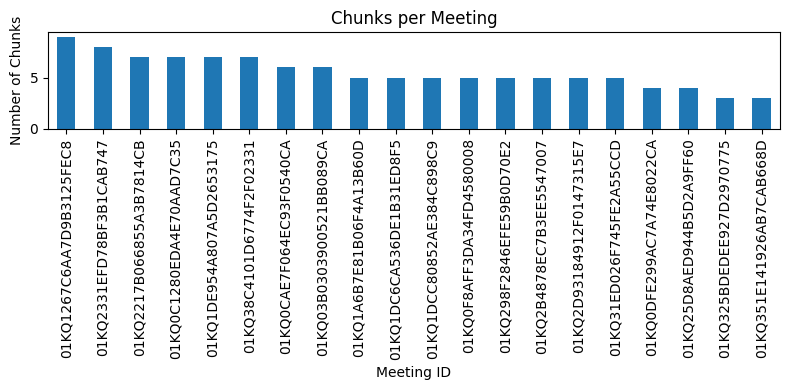

In [37]:
plt.figure(figsize=(8, 4))
chunks_per_meeting.plot(kind="bar")
plt.title("Chunks per Meeting")
plt.xlabel("Meeting ID")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [38]:
chunks_df["turn_count"] = chunks_df["end_turn"] - chunks_df["start_turn"] + 1
chunks_df["word_count"] = chunks_df["chunk_text"].fillna("").apply(lambda x: len(x.split()))

chunks_df[["chunk_id", "chunk_label", "turn_count", "word_count"]].head()

,chunk_id,chunk_label,turn_count,word_count
0,01KQ03B0303900521BB089CA_CHUNK_001,Outage Remediation,7,224
1,01KQ03B0303900521BB089CA_CHUNK_002,Incident Response,3,87
2,01KQ03B0303900521BB089CA_CHUNK_003,Remediation Plan,9,342
3,01KQ03B0303900521BB089CA_CHUNK_004,Customer Communication,4,123
4,01KQ03B0303900521BB089CA_CHUNK_005,Security Monitoring,8,300


In [39]:
small_chunks = chunks_df[chunks_df["turn_count"] <= 2]
large_chunks = chunks_df[chunks_df["turn_count"] >= 20]

print("Small chunks:", len(small_chunks))
print("Large chunks:", len(large_chunks))

Small chunks: 3
Large chunks: 4


In [40]:
large_chunks[
    ["meeting_id", "chunk_id", "chunk_label", "turn_count", "chunk_summary"]
]

,meeting_id,chunk_id,chunk_label,turn_count,chunk_summary
51,01KQ1DCC80852AE384C898C9,01KQ1DCC80852AE384C898C9_CHUNK_005,Competitive Evaluation,25,"Customer evaluates SentinelShield, compares pr..."
92,01KQ2D93184912F0147315E7,01KQ2D93184912F0147315E7_CHUNK_005,Churn Risk,20,Customer considers switching vendors due to ou...
100,01KQ325BDEDEE927D2970775,01KQ325BDEDEE927D2970775_CHUNK_003,Incident Communication,24,"Agent explains Aegis-side cascading failure, a..."
101,01KQ351E141926AB7CAB668D,01KQ351E141926AB7CAB668D_CHUNK_001,Outage Investigation,29,"Agent explains outage, root cause, regulatory ..."


In [41]:
ALLOWED_SENTIMENTS = {
    "neutral",
    "positive",
    "negative",
    "mixed-positive",
    "mixed-negative",
    "very-positive",
    "very-negative",
}

invalid_sentiment_df = chunks_df[
    ~chunks_df["chunk_sentiment"].isin(ALLOWED_SENTIMENTS)
]

invalid_sentiment_df[
    ["meeting_id", "chunk_id", "chunk_label", "chunk_sentiment", "chunk_summary"]
]

,meeting_id,chunk_id,chunk_label,chunk_sentiment,chunk_summary


In [42]:
sentiment_counts = chunks_df["chunk_sentiment"].value_counts()

sentiment_counts

chunk_sentiment
neutral           52
negative          33
positive          13
mixed-negative    10
mixed-positive     3
Name: count, dtype: int64

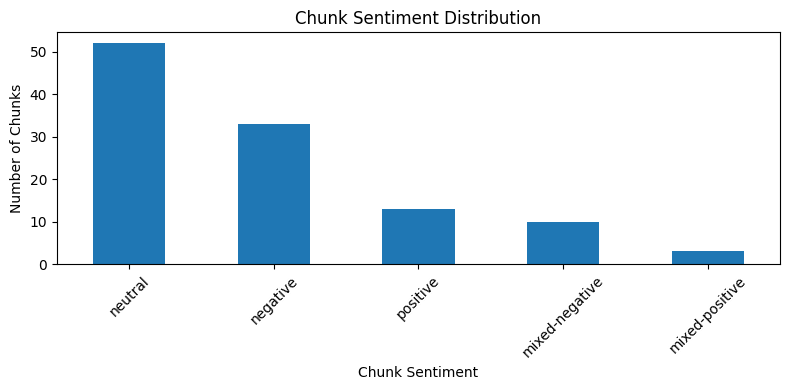

In [43]:
plt.figure(figsize=(8, 4))
sentiment_counts.plot(kind="bar")
plt.title("Chunk Sentiment Distribution")
plt.xlabel("Chunk Sentiment")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
def infer_weak_sentiment_from_turns(counts):
    if not isinstance(counts, dict) or not counts:
        return "unknown"

    total = sum(counts.values())
    positive = counts.get("positive", 0)
    negative = counts.get("negative", 0)
    neutral = counts.get("neutral", 0)

    positive_ratio = positive / total
    negative_ratio = negative / total
    neutral_ratio = neutral / total

    if negative_ratio >= 0.7:
        return "negative"
    if positive_ratio >= 0.7:
        return "positive"
    if neutral_ratio >= 0.8:
        return "neutral"
    if positive > negative:
        return "mixed-positive"
    if negative > positive:
        return "mixed-negative"

    return "neutral"


chunks_df["weak_turn_sentiment"] = chunks_df["turn_sentiment_counts"].apply(
    infer_weak_sentiment_from_turns
)

chunks_df[
    ["chunk_id", "chunk_label", "chunk_sentiment", "weak_turn_sentiment", "turn_sentiment_counts"]
].head()

,chunk_id,chunk_label,chunk_sentiment,weak_turn_sentiment,turn_sentiment_counts
0,01KQ03B0303900521BB089CA_CHUNK_001,Outage Remediation,neutral,neutral,{'neutral': 7}
1,01KQ03B0303900521BB089CA_CHUNK_002,Incident Response,negative,mixed-negative,"{'negative': 2, 'neutral': 1}"
2,01KQ03B0303900521BB089CA_CHUNK_003,Remediation Plan,neutral,neutral,"{'neutral': 8, 'negative': 1}"
3,01KQ03B0303900521BB089CA_CHUNK_004,Customer Communication,neutral,mixed-negative,"{'neutral': 3, 'negative': 1}"
4,01KQ03B0303900521BB089CA_CHUNK_005,Security Monitoring,neutral,neutral,"{'neutral': 7, 'negative': 1}"


In [18]:
def is_sentiment_mismatch(row):
    llm_sentiment = row["chunk_sentiment"]
    weak_sentiment = row["weak_turn_sentiment"]

    if weak_sentiment == "unknown":
        return False

    positive_family = {"positive", "very-positive", "mixed-positive"}
    negative_family = {"negative", "very-negative", "mixed-negative"}

    if llm_sentiment in positive_family and weak_sentiment in negative_family:
        return True

    if llm_sentiment in negative_family and weak_sentiment in positive_family:
        return True

    return False


chunks_df["sentiment_mismatch_flag"] = chunks_df.apply(
    is_sentiment_mismatch,
    axis=1
)

sentiment_mismatch_df = chunks_df[chunks_df["sentiment_mismatch_flag"]]

sentiment_mismatch_df[
    [
        "meeting_id",
        "chunk_id",
        "chunk_label",
        "chunk_sentiment",
        "weak_turn_sentiment",
        "turn_sentiment_counts",
        "chunk_summary",
        "sentiment_reason",
    ]
]

,meeting_id,chunk_id,chunk_label,chunk_sentiment,weak_turn_sentiment,turn_sentiment_counts,chunk_summary,sentiment_reason
45,01KQ1DE954A807A5D2653175,01KQ1DE954A807A5D2653175_CHUNK_002,Documentation & Compliance Review,mixed-negative,mixed-positive,"{'positive': 3, 'neutral': 7, 'negative': 2}",Discuss content status for HIPAA/ISO guides an...,Concerns over documentation delays and support...


actual

In [45]:
chunks_df["turn_count"] = chunks_df["end_turn"] - chunks_df["start_turn"] + 1
chunks_df["word_count"] = chunks_df["chunk_text"].fillna("").apply(lambda x: len(x.split()))

chunks_df[["turn_count", "word_count"]].describe()

,turn_count,word_count
count,111.000000,111.000000
mean,7.756757,259.684685
std,4.653867,180.125713
min,2.000000,14.000000
25%,5.000000,152.500000
50%,7.000000,207.000000
75%,9.000000,308.500000
max,29.000000,1036.000000


In [46]:
small_chunks = chunks_df[chunks_df["turn_count"] <= 2]
large_chunks = chunks_df[chunks_df["turn_count"] >= 20]

print("Small chunks:", len(small_chunks))
print("Large chunks:", len(large_chunks))

pd.concat([small_chunks, large_chunks])[
    ["meeting_id", "chunk_id", "chunk_label", "turn_count", "word_count", "chunk_summary"]
]

Small chunks: 3
Large chunks: 4


,meeting_id,chunk_id,chunk_label,turn_count,word_count,chunk_summary
41,01KQ1A6B7E81B06F4A13B60D,01KQ1A6B7E81B06F4A13B60D_CHUNK_005,Case Closure,2,14,"Agent apologizes, confirms follow-up, ends call."
57,01KQ1DE954A807A5D2653175,01KQ1DE954A807A5D2653175_CHUNK_006,SSO Scope Clarification,2,72,Clarified SSO integration scope for Comply v2.
91,01KQ2D93184912F0147315E7,01KQ2D93184912F0147315E7_CHUNK_004,Incident Escalation,2,99,Customer demands escalation to senior incident...
51,01KQ1DCC80852AE384C898C9,01KQ1DCC80852AE384C898C9_CHUNK_005,Competitive Evaluation,25,974,"Customer evaluates SentinelShield, compares pr..."
92,01KQ2D93184912F0147315E7,01KQ2D93184912F0147315E7_CHUNK_005,Churn Risk,20,802,Customer considers switching vendors due to ou...
100,01KQ325BDEDEE927D2970775,01KQ325BDEDEE927D2970775_CHUNK_003,Incident Communication,24,910,"Agent explains Aegis-side cascading failure, a..."
101,01KQ351E141926AB7CAB668D,01KQ351E141926AB7CAB668D_CHUNK_001,Outage Investigation,29,1036,"Agent explains outage, root cause, regulatory ..."


In [47]:
ALLOWED_SENTIMENTS = {
    "neutral",
    "positive",
    "negative",
    "mixed-positive",
    "mixed-negative",
    "very-positive",
    "very-negative",
}

invalid_sentiment_df = chunks_df[
    ~chunks_df["chunk_sentiment"].isin(ALLOWED_SENTIMENTS)
]

invalid_sentiment_df[
    ["meeting_id", "chunk_id", "chunk_label", "chunk_sentiment", "chunk_summary"]
]

,meeting_id,chunk_id,chunk_label,chunk_sentiment,chunk_summary


In [48]:
label_counts = chunks_df["chunk_label"].value_counts()

print("Unique chunk labels:", chunks_df["chunk_label"].nunique())

label_counts.head(25)

Unique chunk labels: 108


chunk_label
Audit Preparation Overview              2
Meeting Setup                           2
Incident Communication                  2
SLA Risk & Fix Timeline                 1
Post-Mortem & Transparency              1
Platform Outage Impact                  1
Process and Closure                     1
Feature Request Documentation           1
Workaround and RTO Discussion           1
Granular Restore Inquiry                1
Action Items & Wrap-up                  1
Churn Risk Assessment                   1
Platform Separation Clarification       1
Outage Remediation                      1
Documentation Readiness & Scheduling    1
Customer Escalation                     1
Product Outage Ticket Volume            1
Action Plan and Follow-up               1
Compliance Documentation                1
Architecture Assessment                 1
Vendor Confidence and Review            1
Remediation Plan and Timeline           1
Outage Incident Overview                1
Account Introduction  

In [49]:
GENERIC_LABELS = {
    "discussion",
    "conversation",
    "support inquiry",
    "customer inquiry",
    "general inquiry",
    "issue discussion",
    "follow up",
    "follow-up",
}

chunks_df["chunk_label_clean"] = chunks_df["chunk_label"].fillna("").str.lower().str.strip()

generic_label_df = chunks_df[
    chunks_df["chunk_label_clean"].isin(GENERIC_LABELS)
]

generic_label_df[
    ["meeting_id", "chunk_id", "chunk_label", "chunk_summary"]
]

,meeting_id,chunk_id,chunk_label,chunk_summary


In [50]:
manual_review_cols = [
    "meeting_id",
    "meeting_title",
    "chunk_id",
    "start_turn",
    "end_turn",
    "turn_count",
    "chunk_label",
    "chunk_summary",
    "chunk_sentiment",
    "turn_sentiment_counts",
    "matched_provided_topics",
    "chunk_text",
]

chunks_df[manual_review_cols].sample(
    min(10, len(chunks_df)),
    random_state=42
)

,meeting_id,meeting_title,chunk_id,start_turn,end_turn,turn_count,chunk_label,chunk_summary,chunk_sentiment,turn_sentiment_counts,matched_provided_topics,chunk_text
78,01KQ298F2846EFE59B0D70E2,Competitive Threat Assessment - Post Outage,01KQ298F2846EFE59B0D70E2_CHUNK_001,0,3,4,Meeting Setup,Audio check and meeting start.,neutral,{'neutral': 4},[],"Megan Lawson: Okay, I think we've got everyone..."
10,01KQ0C1280EDA4E70AAD7C35,Support Case #9279 - Summit Trust Billing Inquiry,01KQ0C1280EDA4E70AAD7C35_CHUNK_005,25,30,6,Provisioning Cleanup,Agent explains bulk deprovisioning option to r...,neutral,{'neutral': 6},[provisioning],Gregory Fisk: That's fine. I'd appreciate you ...
4,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_005,23,30,8,Security Monitoring,"Agent explains zero visibility, retroactive an...",neutral,"{'neutral': 7, 'negative': 1}",[security monitoring],"Megan Lawson: Raj, on the six hours of no visi..."
84,01KQ2B4878EC7B3EE5547007,Aegis / Stratos Cloud - Audit Preparation,01KQ2B4878EC7B3EE5547007_CHUNK_002,5,8,4,Compliance Process Pain,"Customer describes manual, time‑consuming audi...",negative,"{'neutral': 3, 'negative': 1}","[audit preparation, compliance automation]","Daniel Okafor: Absolutely, and that's exactly ..."
64,01KQ2217B066855A3B7814CB,Aegis / Meridian Capital - Service Reliability...,01KQ2217B066855A3B7814CB_CHUNK_006,34,40,7,Compliance Documentation,"Provided audit summary, compliance discussion,...",mixed-negative,"{'positive': 2, 'neutral': 3, 'negative': 2}","[compliance, incident communication]",Ravi Gupta: We've done a full audit of similar...
68,01KQ2331EFD78BF3B1CAB747,Detect Outage - Customer Impact Assessment,01KQ2331EFD78BF3B1CAB747_CHUNK_003,11,24,14,Internal Monitoring Failure,Root cause identified as single point failure;...,negative,"{'negative': 12, 'neutral': 2}",[internal monitoring failure],"Diana Reeves: That was the right call, Lisa. O..."
30,01KQ1267C6AA7D9B3125FEC8,SOC 2 Audit Preparation - Internal,01KQ1267C6AA7D9B3125FEC8_CHUNK_003,16,22,7,Change Management Process,Plan to tighten change management gate for pro...,negative,"{'neutral': 5, 'negative': 2}",[change management],"Raj Kapoor: Perfect. Okay, change management —..."
45,01KQ1DC6CA536DE1B31ED8F5,Aegis / Atlas Precision - Contract Discussion,01KQ1DC6CA536DE1B31ED8F5_CHUNK_004,28,34,7,Compliance Add‑on,Covered SOC 2 compliance module pricing and bu...,neutral,{'neutral': 7},"[compliance, product add‑on]",Wayne Keller: That works. The other thing I wa...
96,01KQ31ED026F745FE2A55CCD,Identity Team - Q2 Roadmap,01KQ31ED026F745FE2A55CCD_CHUNK_004,34,38,5,Identity Audit Trail,Design identity audit trail schema and Comply ...,neutral,"{'positive': 3, 'neutral': 2}",[compliance integration],Mike Romano: Okay so then the audit trail — th...
11,01KQ0C1280EDA4E70AAD7C35,Support Case #9279 - Summit Trust Billing Inquiry,01KQ0C1280EDA4E70AAD7C35_CHUNK_006,31,34,4,Identity Management Alerts,Agent discusses seat count alert thresholds an...,neutral,{'neutral': 4},[identity management],Gregory Fisk: Perfect. And just — out of curio...


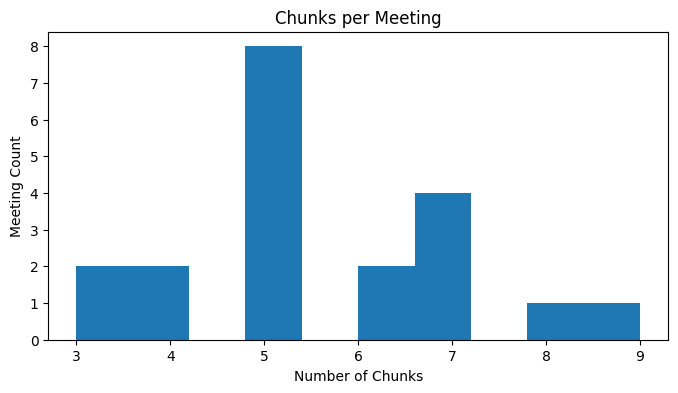

In [51]:
chunks_per_meeting = chunks_df.groupby("meeting_id").size()

plt.figure(figsize=(8, 4))
plt.hist(chunks_per_meeting, bins=10)

plt.title("Chunks per Meeting")
plt.xlabel("Number of Chunks")
plt.ylabel("Meeting Count")

plt.show()

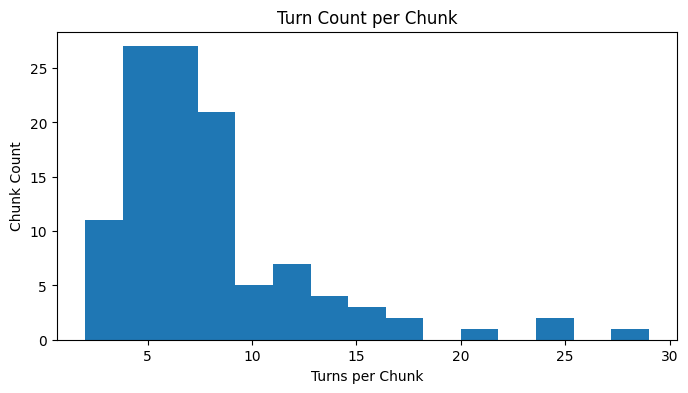

In [52]:
plt.figure(figsize=(8, 4))
plt.hist(chunks_df["turn_count"], bins=15)

plt.title("Turn Count per Chunk")
plt.xlabel("Turns per Chunk")
plt.ylabel("Chunk Count")

plt.show()

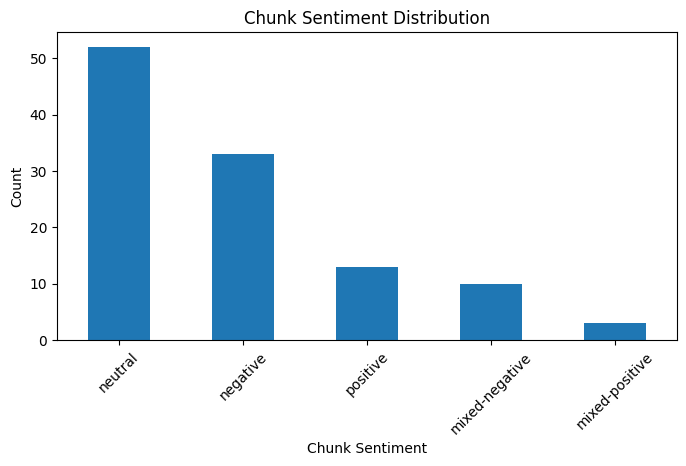

In [53]:
chunks_df["chunk_sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Chunk Sentiment Distribution")
plt.xlabel("Chunk Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

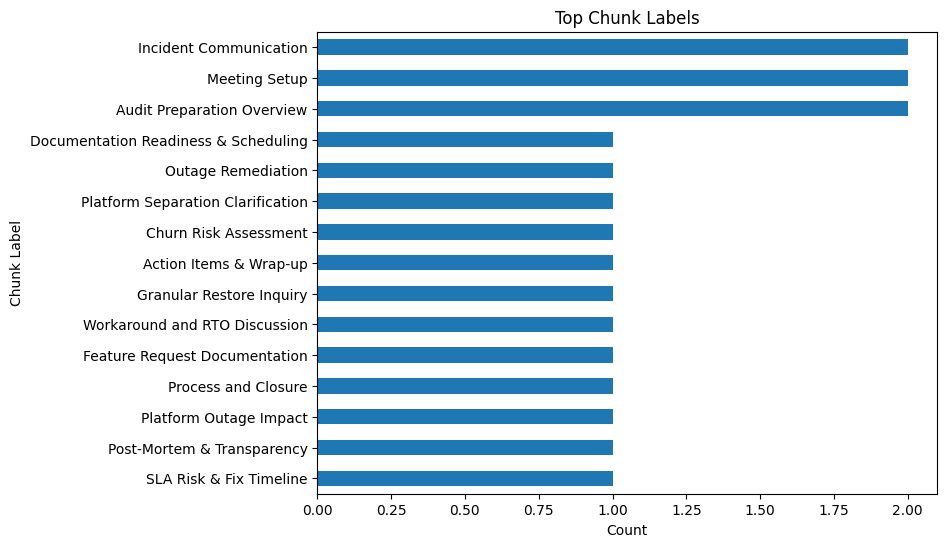

In [54]:
top_labels = chunks_df["chunk_label"].value_counts().head(15)

top_labels.sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top Chunk Labels")
plt.xlabel("Count")
plt.ylabel("Chunk Label")

plt.show()

In [29]:
label_counts = (
    chunks_df["chunk_label"]
    .value_counts()
    .reset_index()
)

label_counts.columns = ["chunk_label", "count"]

label_counts.head(30)

,chunk_label,count
0,Outage Overview & Root Cause,1
1,Incident Communication Planning,1
2,Feature Request Process & Closure,1
3,Feature Request Specification,1
4,Workaround Pain & RTO Requirements,1
5,Environment & Current Restore Process,1
6,Incident Overview,1
7,Action Items & Closure,1
8,Churn Risk & Escalation Management,1
9,Platform Assurance & Customer Messaging,1


In [30]:
chunks_df["normalized_label"] = (
    chunks_df["chunk_label"]
    .str.lower()
    .str.strip()
)

normalized_label_counts = (
    chunks_df["normalized_label"]
    .value_counts()
    .reset_index()
)

normalized_label_counts.columns = ["normalized_label", "count"]

normalized_label_counts.head(30)

,normalized_label,count
0,outage overview & root cause,1
1,incident communication planning,1
2,feature request process & closure,1
3,feature request specification,1
4,workaround pain & rto requirements,1
5,environment & current restore process,1
6,incident overview,1
7,action items & closure,1
8,churn risk & escalation management,1
9,platform assurance & customer messaging,1


In [31]:
from rapidfuzz import fuzz

labels = chunks_df["normalized_label"].dropna().unique()

similar_pairs = []

for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        score = fuzz.ratio(labels[i], labels[j])

        if score >= 80:
            similar_pairs.append({
                "label_1": labels[i],
                "label_2": labels[j],
                "similarity": score
            })

similar_labels_df = pd.DataFrame(similar_pairs)

similar_labels_df.sort_values(
    "similarity",
    ascending=False
).head(50)

,label_1,label_2,similarity
1,meeting introduction & iso context,meeting introduction & audit context,91.428571
0,outage overview & root cause,outage & root cause,80.851064
